In [44]:
import matplotlib.pyplot as plt
import pandas as pd

In [45]:
dfs = {}
years = ['2021', '2022', '2023', '2024', '2025']

for year in years:
    dfs[year] = pd.read_csv(f'financial_data_{year}.csv')

/var/folders/9r/612l79zx42z643jnmxxshb1m0000gn/T/ipykernel_1226/448918627.py:5: DtypeWarning: Columns (0: expl2510) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs[year] = pd.read_csv(f'financial_data_{year}.csv')
/var/folders/9r/612l79zx42z643jnmxxshb1m0000gn/T/ipykernel_1226/448918627.py:5: DtypeWarning: Columns (0: expl2300, 1: expl2900, 2: expl2100, 3: expl2500, 4: expl2310, 5: expl2510) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs[year] = pd.read_csv(f'financial_data_{year}.csv')
/var/folders/9r/612l79zx42z643jnmxxshb1m0000gn/T/ipykernel_1226/448918627.py:5: DtypeWarning: Columns (0: expl2400, 1: expl2900, 2: expl2100, 3: expl2500) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs[year] = pd.read_csv(f'financial_data_{year}.csv')
/var/folders/9r/612l79zx42z643jnmxxshb1m0000gn/T/ipykernel_1226/448918627.py:5: DtypeWarning: Columns (0: expl2300, 1: expl2900, 2: expl2500, 3: expl2310) hav

**Готовим данные для EBITA**

In [47]:
years = ['2021', '2022', '2023', '2024', '2025']
df_for_EBITA = {year: pd.DataFrame() for year in years}

for year in years:
    df_for_EBITA[year]['Чистая прибыль'] = dfs[year]['current2400']
    df_for_EBITA[year]['Налог на прибыль'] = dfs[year]['current2410']
    df_for_EBITA[year]['Проценты к уплате'] = dfs[year]['current2330']
    df_for_EBITA[year]['Проценты к получению'] = dfs[year]['current2320']

In [48]:
for year in years:
    df_for_EBITA[year]['EBITA'] = df_for_EBITA[year]['Чистая прибыль']
    + df_for_EBITA[year]['Налог на прибыль']
    + df_for_EBITA[year]['Проценты к уплате']
    - df_for_EBITA[year]['Проценты к получению']

**Анализируем EBITA**

=== РОСТ СУММАРНОЙ EBITA ===
2021 → 2022: 36.9%
2022 → 2023: 28.9%
2023 → 2024: 8.7%
2024 → 2025: -24.3%

=== ДОЛЯ ПРИБЫЛЬНЫХ ===
2021: 83.0%
2022: 80.2%
2023: 78.7%
2024: 77.8%
2025: 72.5%

=== РАЗБРОС (CV) ===
2021: 2031%
2022: 894%
2023: 713%
2024: 745%
2025: 950%


/var/folders/9r/612l79zx42z643jnmxxshb1m0000gn/T/ipykernel_1226/457029547.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1, 1].legend()


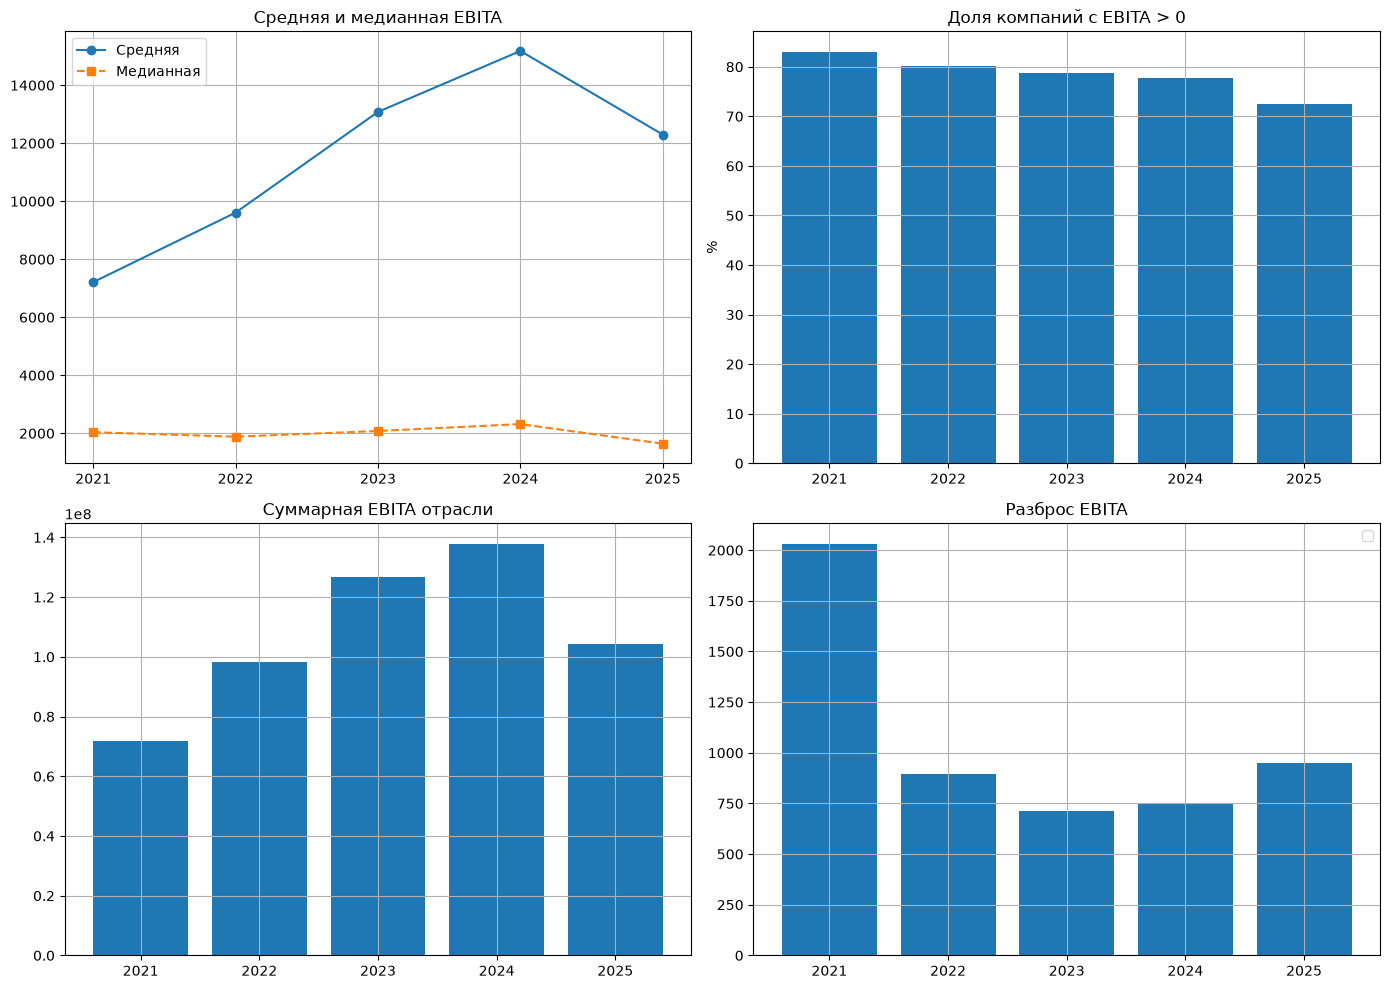


=== СВОДНАЯ ТАБЛИЦА ===
 Год Средняя EBITA Медианная EBITA Суммарная EBITA Прибыльные, %
2021         7,211           2,038      71,810,076          83.0
2022         9,608           1,883      98,329,279          80.2
2023        13,080           2,080     126,709,864          78.7
2024        15,181           2,318     137,785,054          77.8
2025        12,298           1,642     104,340,131          72.5


In [52]:
mean_EBITA = []
median_EBITA = []
total_EBITA = []
profitable_share = []

for year in years:
    df = df_for_EBITA[year]
    mean_EBITA.append(df['EBITA'].mean())
    median_EBITA.append(df['EBITA'].median())
    total_EBITA.append(df['EBITA'].sum())
    profitable_share.append((df['EBITA'] > 0).sum() / df['EBITA'].count() * 100)

# Рост EBITA
print("=== РОСТ СУММАРНОЙ EBITA ===")
for i in range(1, len(years)):
    growth = (total_EBITA[i] - total_EBITA[i-1]) / abs(total_EBITA[i-1]) * 100
    print(f"{years[i-1]} → {years[i]}: {growth:.1f}%")

# Доля прибыльных
print("\n=== ДОЛЯ ПРИБЫЛЬНЫХ ===")
for year, share in zip(years, profitable_share):
    print(f"{year}: {share:.1f}%")

# Разброс
print("\n=== РАЗБРОС (CV) ===")
cv_values = []
for year in years:
    df = df_for_EBITA[year]
    cv = df['EBITA'].std() / df['EBITA'].mean() * 100
    cv_values.append(cv)
    print(f"{year}: {cv:.0f}%")

# Графики
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(years, mean_EBITA, 'o-', label='Средняя')
axes[0, 0].plot(years, median_EBITA, 's--', label='Медианная')
axes[0, 0].set_title('Средняя и медианная EBITA')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].bar(years, profitable_share)
axes[0, 1].set_title('Доля компаний с EBITA > 0')
axes[0, 1].set_ylabel('%')
axes[0, 1].grid(True)

axes[1, 0].bar(years, total_EBITA)
axes[1, 0].set_title('Суммарная EBITA отрасли')
axes[1, 0].grid(True)

axes[1, 1].bar(years, cv_values)
axes[1, 1].set_title('Разброс EBITA')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Сводная таблица
summary = pd.DataFrame({
    'Год': years,
    'Средняя EBITA': [f'{x:,.0f}' for x in mean_EBITA],
    'Медианная EBITA': [f'{x:,.0f}' for x in median_EBITA],
    'Суммарная EBITA': [f'{x:,.0f}' for x in total_EBITA],
    'Прибыльные, %': [f'{x:.1f}' for x in profitable_share]
})
print("\n=== СВОДНАЯ ТАБЛИЦА ===")
print(summary.to_string(index=False))

****Наблюдения и выводы****

**1. Провал в 2025 году**\
Серьезный\
\
**2. Прибыльных компаний все меньше**\
В 2025 каждый четвертый в убытке\
\
**3. Разрыв между средней и медианной растёт**\
Т.е. богатые богатеют, бедные беднеют\
\
**4. До 24 года был рост**\
Cкорее всего, за счет инфляции просто
\
\
**Вывод**\
Отрасль не перспективна сейчас. Все вышеперечисленное говорит о системном кризисе. Крупные игроки еще держатся, но тоже им плохо. Если инвестировать, то только в них. В дальнейшем отрасль тоже, видимо, будет сжиматься. Малые компании на грани вымирания